# Scenario A -- BMA-SMC² walkthrough

Run the (slow) SMC² step once (cached to `results/`), then freely restyle
each figure in its own cell below -- without re-running SMC² -- by editing
the `style` dict (colors, labels, font sizes, `ylim`, ...) and re-running
just that cell.

Run this notebook from its own folder (`simulation_study/`); the first cell
points Python at the repo root regardless of where you move the notebook.


In [1]:
import sys, os

# Locate the repo root by walking up from the current working directory
# until we find requirements.txt -- this works no matter where Jupyter
# happened to start (repo root, this notebook's own folder, etc.), unlike
# assuming a fixed "..".
def find_repo_root(start="."):
    path = os.path.abspath(start)
    while not os.path.exists(os.path.join(path, "requirements.txt")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(
                "Could not find the repo root (no requirements.txt found "
                "above the current directory). Set REPO_ROOT manually, e.g. "
                'REPO_ROOT = "/home/you/Downloads/repo"'
            )
        path = parent
    return path

REPO_ROOT = find_repo_root()
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")

import matplotlib
%matplotlib inline


Repo root: /home/dhorasso/Downloads/bma_smc2_repo/repo


## 1. Load / generate the data, then run BMA-SMC² once (cached)

In [2]:
from simulation_study.scenario_A import *
from src.scenario_runner import run_bma_smc2

replicates = load_or_generate_replicates(
    simulate_one_replicate, n_reps=N_REPS, base_seed=BASE_SEED, out_dir=DATA_DIR,
)

# Analysis runs on a single replicate (index 0 below). Change `replicate_idx`
# to inspect a different one -- note this changes CACHE_PATH's meaning, so
# either edit CACHE_PATH too or delete the old cache file first.
replicate_idx = 0
full_data = replicates[replicate_idx]
days = len(full_data) - FDAY
observed_data = full_data[:days]

smc2_results = run_bma_smc2(
    model_seir=stochastic_seir_model,
    model_dthp=dthp_model,
    state_info_seir=STATE_INFO_SEIR,
    theta_info_seir=THETA_INFO_SEIR,
    state_info_dthp=STATE_INFO_DTHP,
    theta_info_dthp=THETA_INFO_DTHP,
    observed_data=observed_data,
    forecast_days=FDAY,
    N_pop=N_POP,
    observation_distribution=obs_dist_negative_binomial,
    cache_path=CACHE_PATH,   # loads instead of recomputing if this already exists
    # force_rerun=True,      # uncomment to ignore the cache and refit
)


Loading 10 cached replicates from data/simulated/scenario_A/


BMA-SMC^2 Progress: 100%|███████████████████████| 80/80 [31:13<00:00, 23.42s/it]


Results cached to: results/simulated/scenario_A/rep0.pkl


## 2. Model weight

Edit `window` / `t_burning` (window length / burn-in for the sliding-window
model weight) or anything in `style` and re-run this cell -- it's just
plotting, no SMC² recomputation.

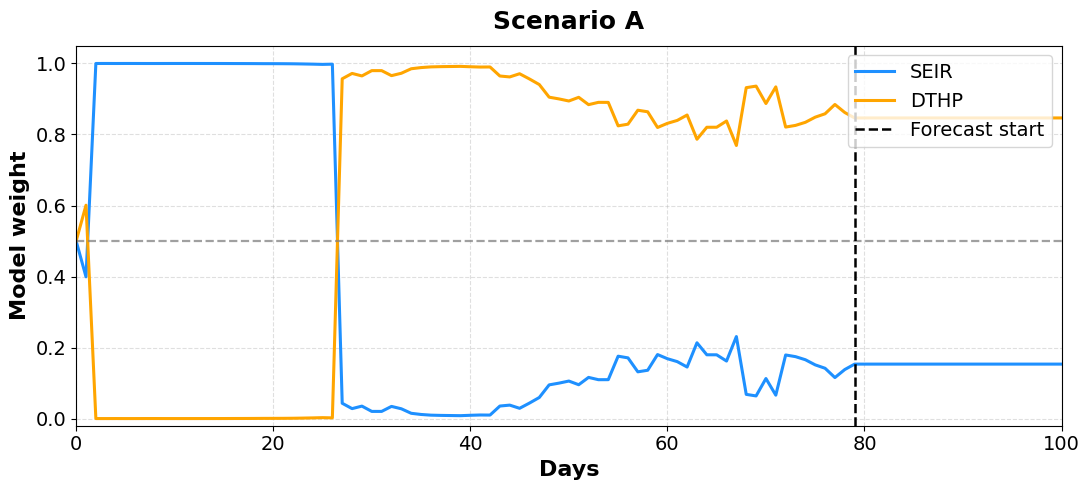

Figure saved to: figures/simulated/scenario_A/model_weight.pdf


In [3]:
from src.scenario_runner import plot_model_weight

w_dthp, w_seir = plot_model_weight(
    smc2_results, forecast_days=FDAY, title=SCENARIO_NAME, figures_dir=FIGURES_DIR,
    window=25, t_burning=0,
    style={
        "color_dthp": "orange", "color_seir": "dodgerblue",
        "label_dthp": "DTHP", "label_seir": "SEIR",
        "ylim_weight": (-0.02, 1.05),
        "fontsize_label": 16, "fontsize_tick": 14, "fontsize_legend": 14,
    },
)


## 3. Parameter estimates (posterior trajectory vs. true value)

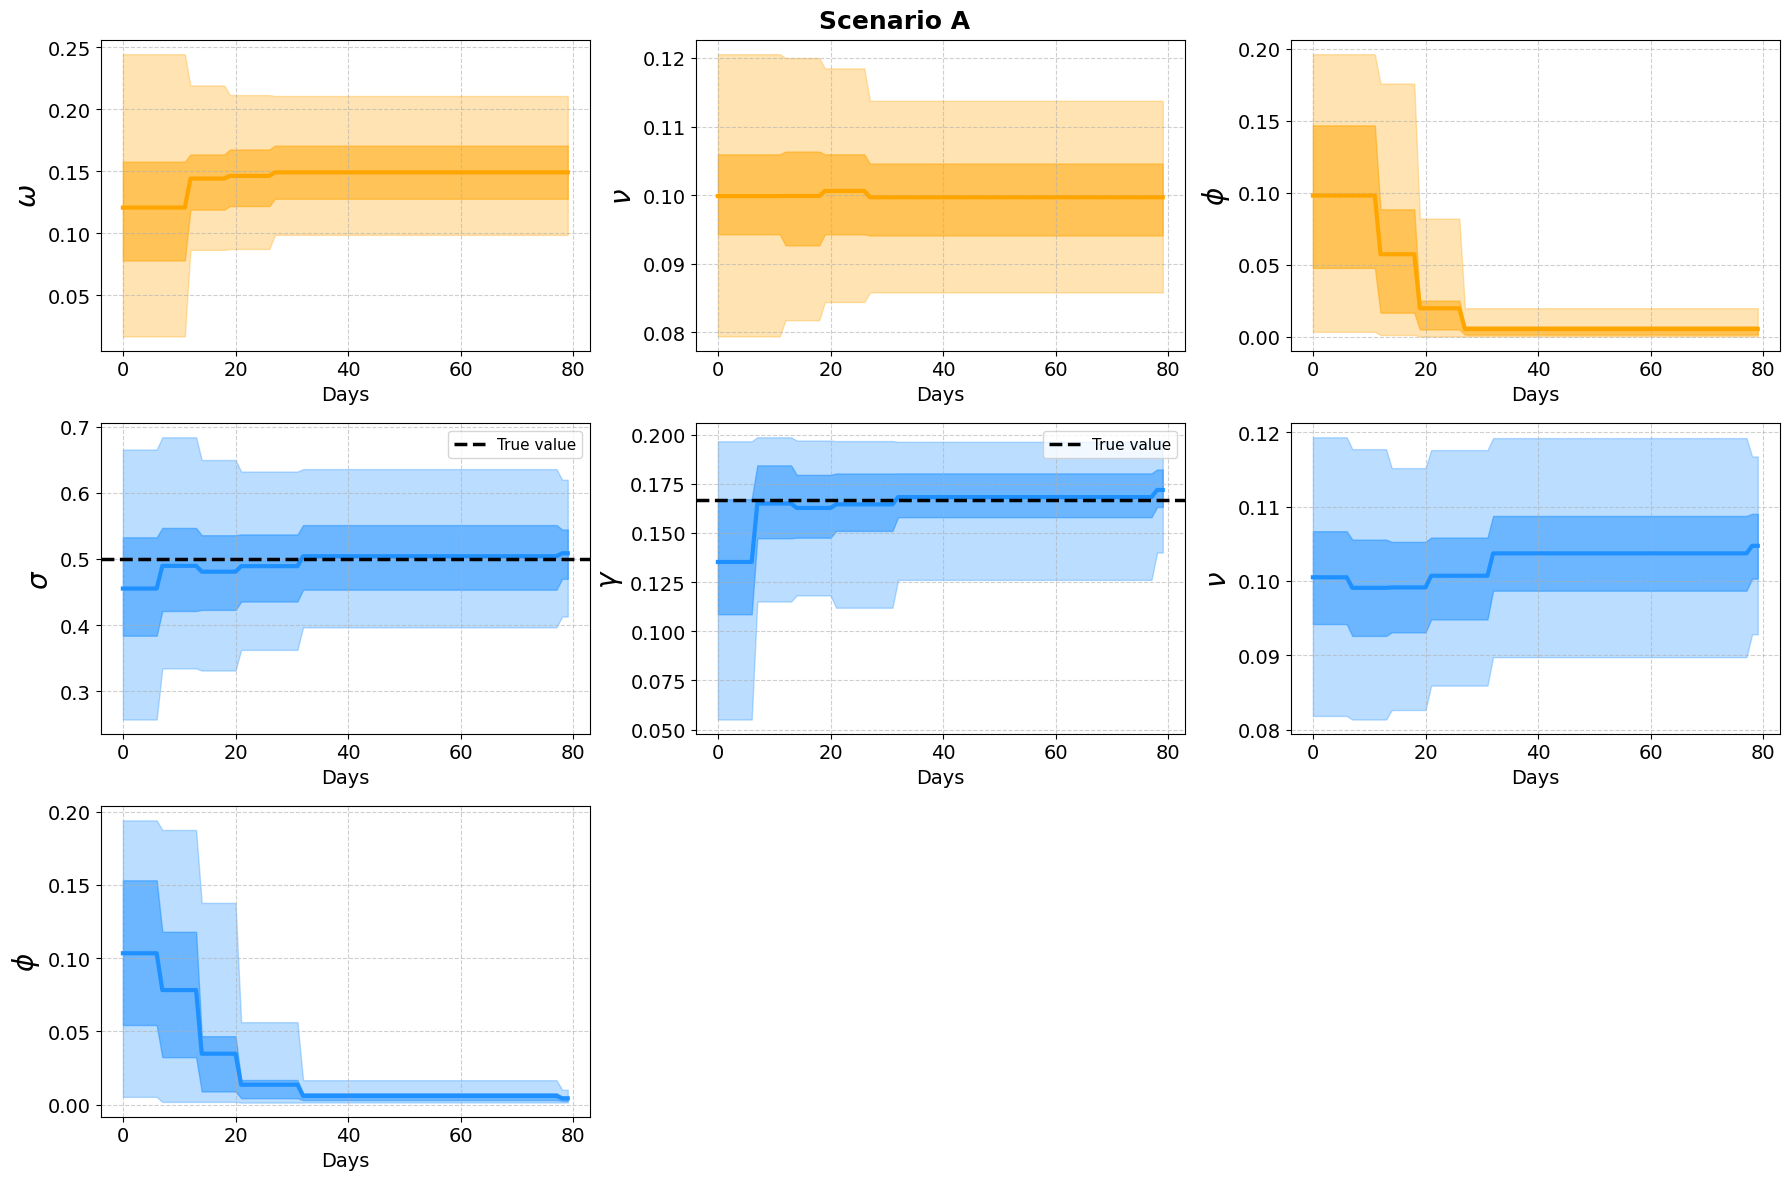

Figure saved to: figures/simulated/scenario_A/param_estimates.pdf


In [4]:
from src.scenario_runner import plot_param_estimates

plot_param_estimates(
    smc2_results, title=SCENARIO_NAME, figures_dir=FIGURES_DIR,
    param_labels=PARAM_LABELS, true_values=TRUE_VALUES, ncols=3,
    style={
        "ylim_param": None,   # e.g. (0, 1) to force the same y-range on every panel
        "fontsize_label": 16, "fontsize_tick": 14,
    },
)


## 4. Model evidence (likelihood)

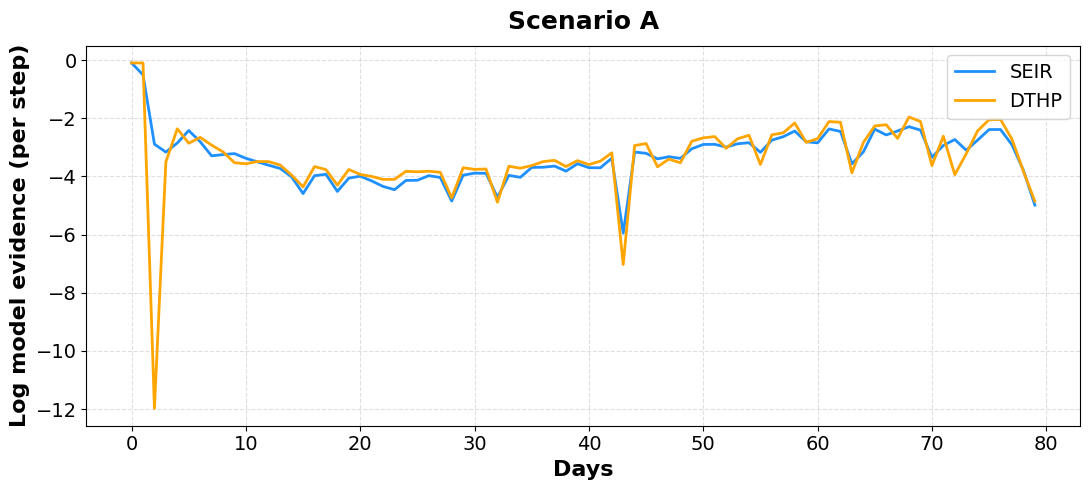

Figure saved to: figures/simulated/scenario_A/likelihood.pdf


In [5]:
from src.scenario_runner import plot_likelihood

plot_likelihood(
    smc2_results, title=SCENARIO_NAME, figures_dir=FIGURES_DIR,
    style={"color_dthp": "orange", "color_seir": "dodgerblue"},
)


## 5. Incidence / R_t fit + forecast

Needs the full dataset (fit + forecast) for the observed points and the true
$R_t$ line -- `full_data` from cell 1 already has both.

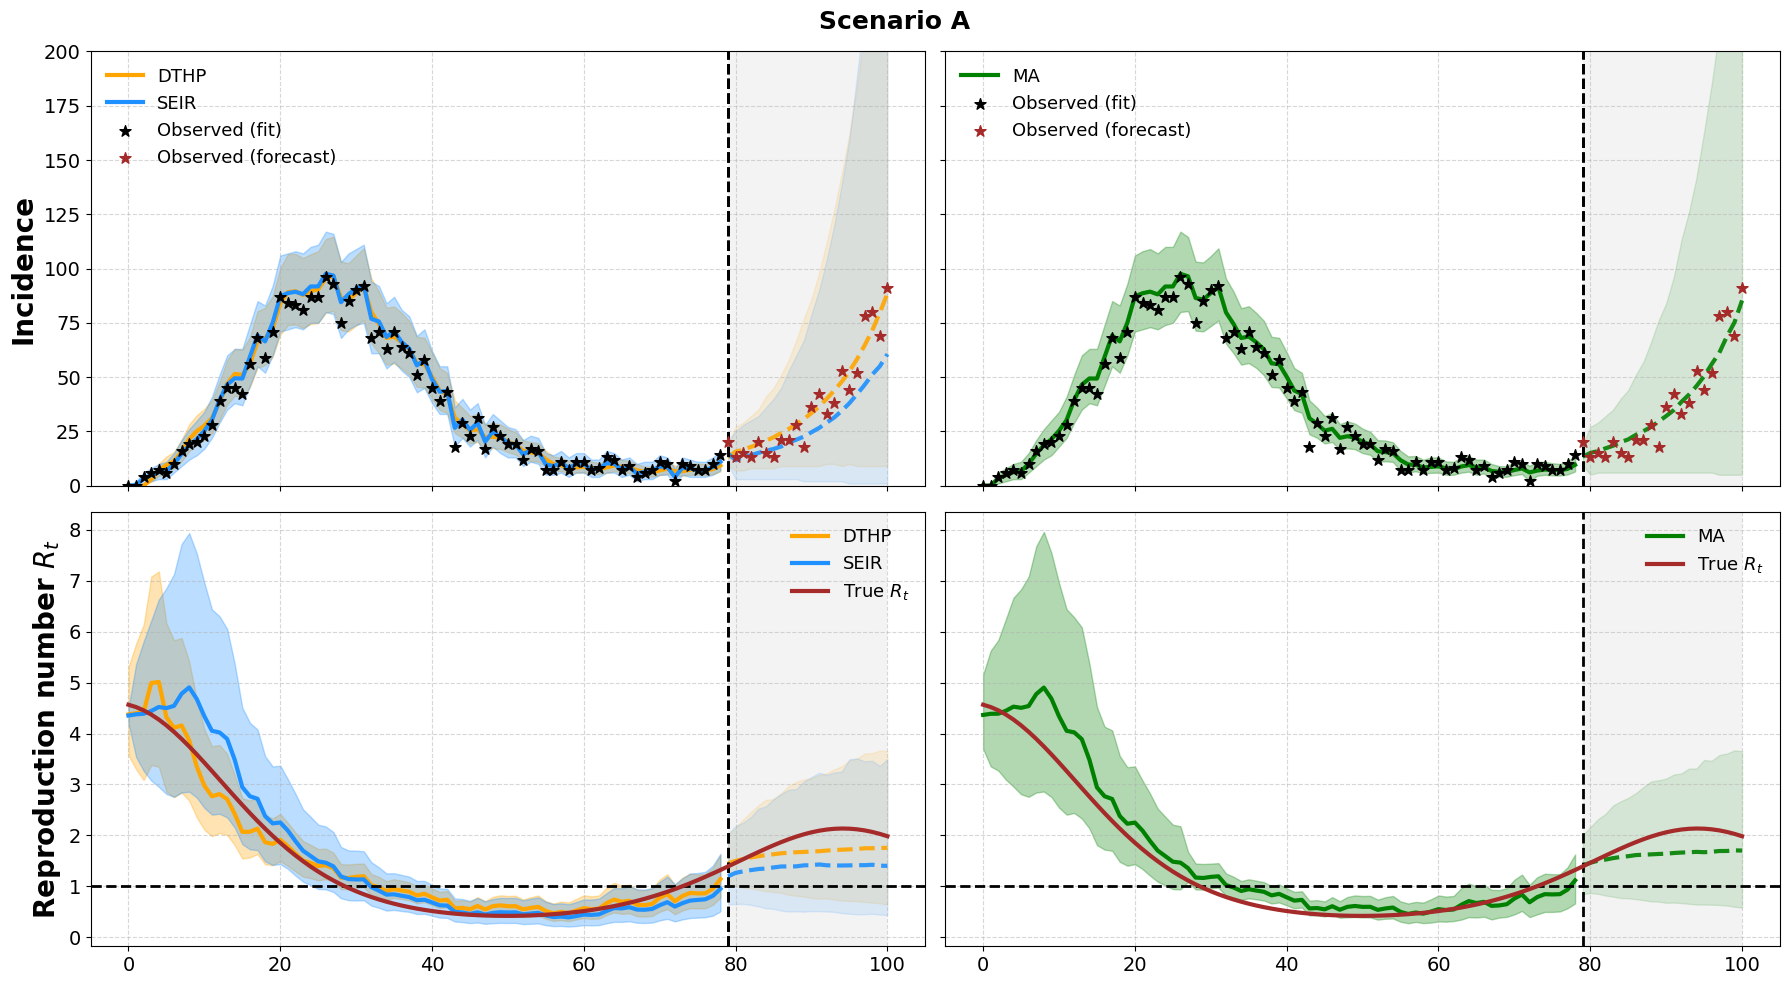

Figure saved to: figures/simulated/scenario_A/fit.pdf


In [6]:
from src.scenario_runner import plot_fit

separation_point = full_data["time"].iloc[days - 1]
forecast_end = full_data["time"].iloc[-1]

plot_fit(
    smc2_results, full_data=full_data, w_dthp=w_dthp, w_seir=w_seir,
    separation_point=separation_point, forecast_end=forecast_end,
    title=SCENARIO_NAME, figures_dir=FIGURES_DIR, true_rt_col="Rt",
    style={
        "color_dthp": "orange", "color_seir": "dodgerblue", "color_ma": "green",
        "ylim_incidence": (0,200), "ylim_rt": None,
    },
)


## 6. Force a fresh SMC² run

Delete the cache file, or pass `force_rerun=True` in cell 1, if you've
changed the priors, the data, or want a new random seed.

In [7]:
# os.remove(CACHE_PATH)  # then re-run cell 1
